Phase 1: Load & understand the dataset

       id                                     title  adult original_language  \
0  195554         Panorama of Galveston Power House  False                en   
1  105303                  Explosion of a Motor Car  False                xx   
2  195553      Panorama of Orphans' Home, Galveston  False                en   
3  195569       Panorama of Wreckage of Water Front  False                en   
4  195542  Bird's-Eye View of Dock Front, Galveston  False                en   

  origin_country release_date      genre_names production_company_names  \
0         ['US']   1900-05-21               []                       []   
1         ['GB']   1900-07-01       ['Comedy']             ['Hepworth']   
2         ['US']   1900-09-21               []                       []   
3         ['US']   1900-09-21  ['Documentary']       ['Edison Studios']   
4         ['US']   1900-09-21  ['Documentary']       ['Edison Studios']   

        budget      revenue  runtime  popularity  vote_average  vote

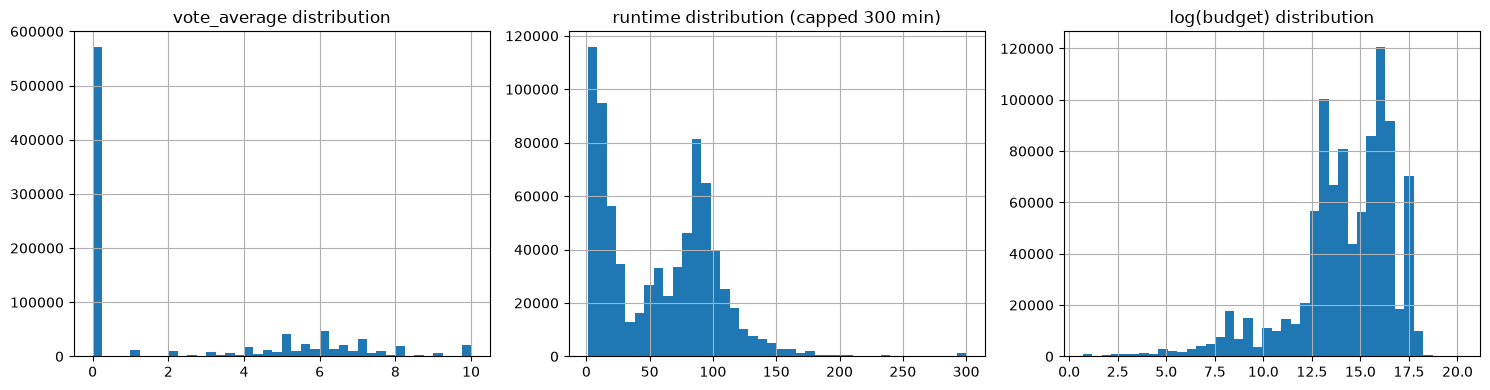

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'F:\pypy3\Movie-success\data_movies_clean.csv')
print(df.head())
print(df['genre_names'].iloc[0])
print(df['production_company_names'].iloc[0])
print(df[['budget', 'revenue', 'runtime', 'popularity',
          'vote_average', 'vote_count']].describe())
0
print("Zero budget:  ", (df['budget'] == 0).sum())
print("Zero revenue: ", (df['revenue'] == 0).sum())
print("Zero runtime: ", (df['runtime'] == 0).sum())
print("vote_average == 0:", (df['vote_average'] == 0).sum())
print("vote_count < 10:  ", (df['vote_count'] < 10).sum())

#adult content breakdown
print("\nadult value counts:")
print(df['adult'].value_counts())

#language breakdown (top 10)
print("\nTop languages:")
print(df['original_language'].value_counts().head(10))

#origin_country — might be a list string like "['US', 'GB']"
print("\nSample origin_country:", df['origin_country'].iloc[:5].tolist())

#How many rows survive each filter
has_rating  = (df['vote_average'] > 0) & (df['vote_count'] >= 10)
has_revenue = (df['revenue'] > 0)
has_budget  = (df['budget'] > 0)
both_money  = has_revenue & has_budget

print("Rows with valid rating (≥10 votes): ", has_rating.sum())
print("Rows with revenue > 0:              ", has_revenue.sum())
print("Rows with budget > 0:               ", has_budget.sum())
print("Rows with both budget & revenue:    ", both_money.sum())

#See what the strings look like
print(df['genre_names'].value_counts().head(10))
print()
print(df['production_company_names'].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['vote_average'].hist(bins=40, ax=axes[0])
axes[0].set_title('vote_average distribution')

df[df['runtime'] > 0]['runtime'].clip(upper=300).hist(bins=40, ax=axes[1])
axes[1].set_title('runtime distribution (capped 300 min)')

np.log1p(df[df['budget'] > 0]['budget']).hist(bins=40, ax=axes[2])
axes[2].set_title('log(budget) distribution')

plt.tight_layout()
plt.show()

Phase 2: Clean

In [ ]:
import ast

# ── 1. Drop the 9 rows with missing titles ────────────────────────────
df = df.dropna(subset=['title'])

# ── 2. Filter to rows worth modeling ─────────────────────────────────
# Only keep movies with enough votes to have a meaningful rating
df = df[df['vote_count'] >= 10].copy()
print(f"After vote filter: {len(df):,} rows")   # ~93,354

# ── 3. Filter bad runtimes ────────────────────────────────────────────
df = df[(df['runtime'] > 0) & (df['runtime'] <= 300)].copy()
print(f"After runtime filter: {len(df):,} rows")

# ── 4. Parse list-string columns ──────────────────────────────────────
def safe_parse(x):
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except:
        return []

df['genres']    = df['genre_names'].apply(safe_parse)
df['countries'] = df['origin_country'].apply(safe_parse)

# ── 5. Convert release_date and extract parts ─────────────────────────
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# ── 6. Drop the adult column (only 1 True row — useless as a feature) ─
df = df.drop(columns=['adult'])

print(f"\nFinal clean shape: {df.shape}")
print(df[['title', 'vote_average', 'runtime', 'genres', 'release_year']].head())

After vote filter: 93,354 rows
After runtime filter: 92,464 rows

Final clean shape: (92464, 17)
                          title  vote_average  runtime  \
1      Explosion of a Motor Car           6.1        2   
8         The Enchanted Drawing           6.4        2   
10  As Seen Through a Telescope           5.5        1   
11         Conquering the Skies           4.7        1   
13     The Old Maid's Valentine           3.8        1   

                          genres  release_year  
1                       [Comedy]          1900  
8   [Animation, Comedy, Fantasy]          1900  
10                      [Comedy]          1900  
11             [Science Fiction]          1901  
13             [Comedy, Romance]          1900  


Top 10 genres: ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action', 'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation']


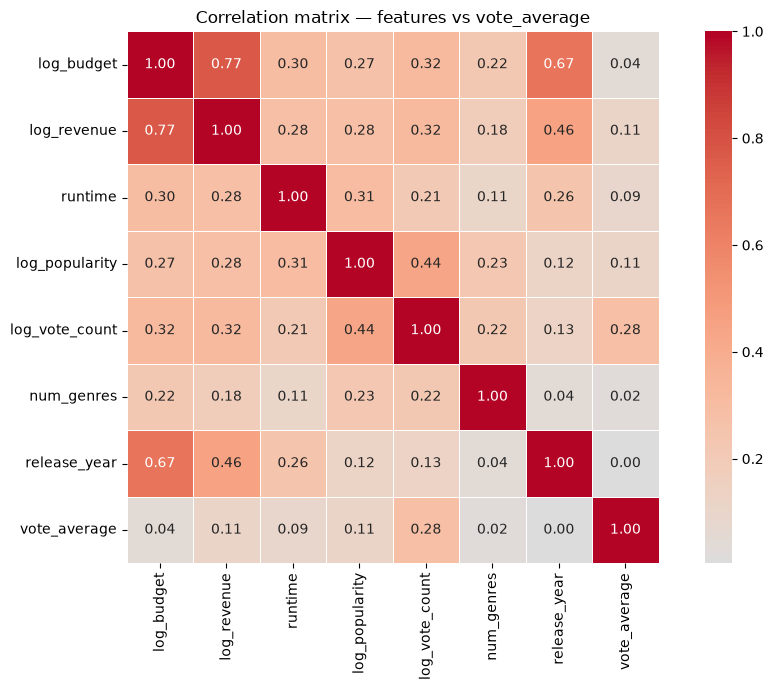

In [ ]:
from collections import Counter

# ── 1. Log-transform skewed columns ──────────────────────────────────
df['log_budget']     = np.log1p(df['budget'])
df['log_revenue']    = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_vote_count'] = np.log1p(df['vote_count'])

# ── 2. Genre features ─────────────────────────────────────────────────
df['num_genres'] = df['genres'].apply(len)

all_genres = [g for sublist in df['genres'] for g in sublist]
top_genres = [g for g, _ in Counter(all_genres).most_common(10)]
print("Top 10 genres:", top_genres)

for g in top_genres:
    df[f'genre_{g}'] = df['genres'].apply(lambda x: int(g in x))

# ── 3. Language & country ─────────────────────────────────────────────
df['is_english']     = (df['original_language'] == 'en').astype(int)
df['primary_country'] = df['countries'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

# ── 4. Correlation heatmap ────────────────────────────────────────────
numeric_cols = [
    'log_budget', 'log_revenue', 'runtime', 'log_popularity',
    'log_vote_count', 'num_genres', 'release_year', 'vote_average'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation matrix — features vs vote_average')
plt.tight_layout()
plt.show()

Check 1: Genre distribution

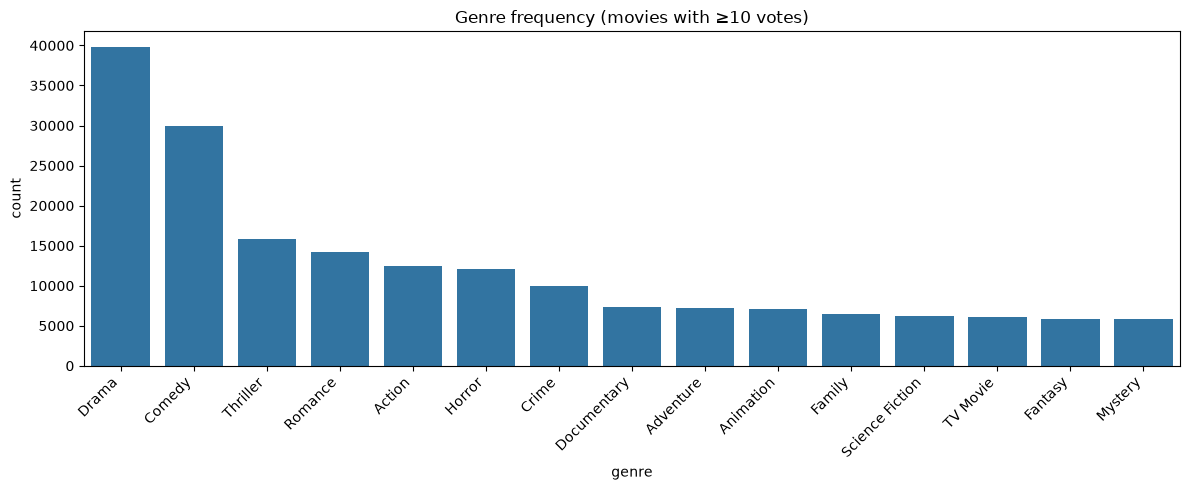

In [12]:
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count'])
genre_df = genre_df.sort_values('count', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=genre_df.head(15), x='genre', y='count')
plt.xticks(rotation=45, ha='right')
plt.title('Genre frequency (movies with ≥10 votes)')
plt.tight_layout()
plt.show()

Check 2: vote_average distribution

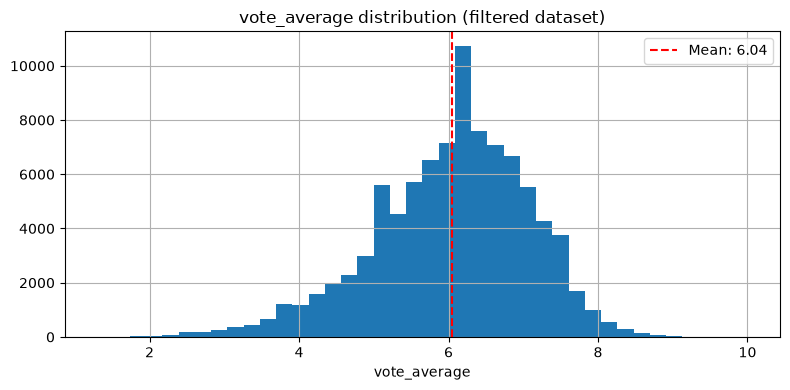

In [13]:
plt.figure(figsize=(8, 4))
df['vote_average'].hist(bins=40, edgecolor='none')
plt.axvline(df['vote_average'].mean(), color='red',
            linestyle='--', label=f"Mean: {df['vote_average'].mean():.2f}")
plt.title('vote_average distribution (filtered dataset)')
plt.xlabel('vote_average')
plt.legend()
plt.tight_layout()
plt.show()

Check: Pre-1950 films

In [14]:
print(df['release_year'].value_counts().sort_index().head(20))

era_counts = pd.cut(df['release_year'],
                    bins=[1800, 1950, 1980, 2000, 2010, 2030],
                    labels=['pre-1950', '1950–1980', '1980–2000',
                            '2000–2010', '2010+'])
print(era_counts.value_counts().sort_index())

release_year
1900    70
1901    42
1902    29
1903    51
1904    35
1905    62
1906    34
1907    39
1908    36
1909    34
1910    22
1911    35
1912    44
1913    32
1914    66
1915    43
1916    44
1917    36
1918    33
1919    55
Name: count, dtype: int64
release_year
pre-1950      6276
1950–1980    13688
1980–2000    15200
2000–2010    16849
2010+        40451
Name: count, dtype: int64


Phase 4: Feature matrix

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ── 1. Define features based on correlation results ───────────────────
# Dropping: log_budget (0.04), release_year (0.00), num_genres (0.02)
# Keeping: everything with meaningful correlation to vote_average

genre_features = [f'genre_{g}' for g in top_genres]

FEATURES = [
    'log_revenue',       # 0.11
    'runtime',           # 0.09
    'log_popularity',    # 0.11
    'log_vote_count',    # 0.28 strongest predictor
    'is_english',        # language signal
    'release_month',     # seasonal release patterns
] + genre_features

TARGET = 'vote_average'

# ── 2. Build clean modeling DataFrame ─────────────────────────────────
model_df = df[FEATURES + [TARGET]].dropna()
print(f"Modeling dataset: {model_df.shape}")
print(f"Features used: {len(FEATURES)}")

X = model_df[FEATURES]
y = model_df[TARGET]

Modeling dataset: (92464, 17)
Features used: 16


In [ ]:
# ── 3. Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── 4. Scale ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: (73971, 16), Test: (18493, 16)


In [17]:
# ── 5. Train ──────────────────────────────────────────────────────────
models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge':             (Ridge(alpha=1.0),    True),
    'Random Forest':     (RandomForestRegressor(
                            n_estimators=100,
                            max_depth=10,
                            min_samples_leaf=10,
                            random_state=42,
                            n_jobs=-1        # uses all CPU cores
                         ), False),
}

results = {}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {
        'model':  model,
        'preds':  preds,
        'rmse':   rmse,
        'r2':     r2,
    }
    print(f"{name:22s} → RMSE: {rmse:.3f}  R²: {r2:.3f}")

Linear Regression      → RMSE: 0.871  R²: 0.308
Ridge                  → RMSE: 0.871  R²: 0.308
Random Forest          → RMSE: 0.809  R²: 0.403


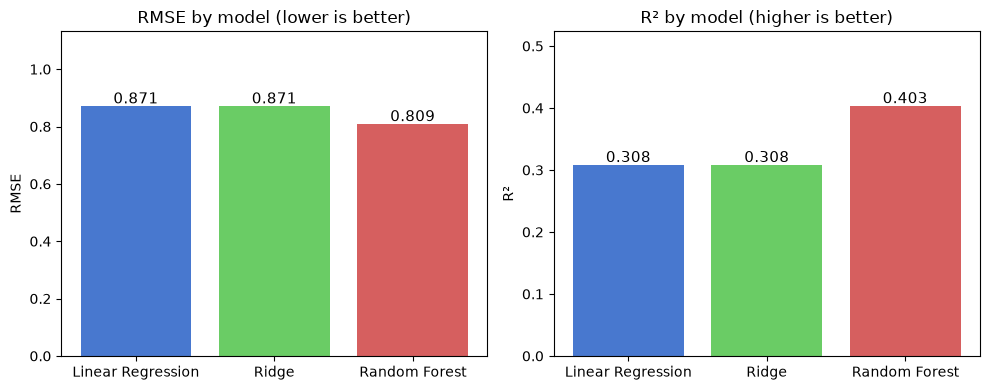

In [18]:
#Comparison plot

names = list(results.keys())
rmses = [results[n]['rmse'] for n in names]
r2s   = [results[n]['r2']   for n in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(names, rmses, color=['#4878CF', '#6ACC65', '#D65F5F'])
axes[0].set_title('RMSE by model (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmses) * 1.3)
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

axes[1].bar(names, r2s, color=['#4878CF', '#6ACC65', '#D65F5F'])
axes[1].set_title('R² by model (higher is better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, max(r2s) * 1.3)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Phase 5: Evaluate & visualize

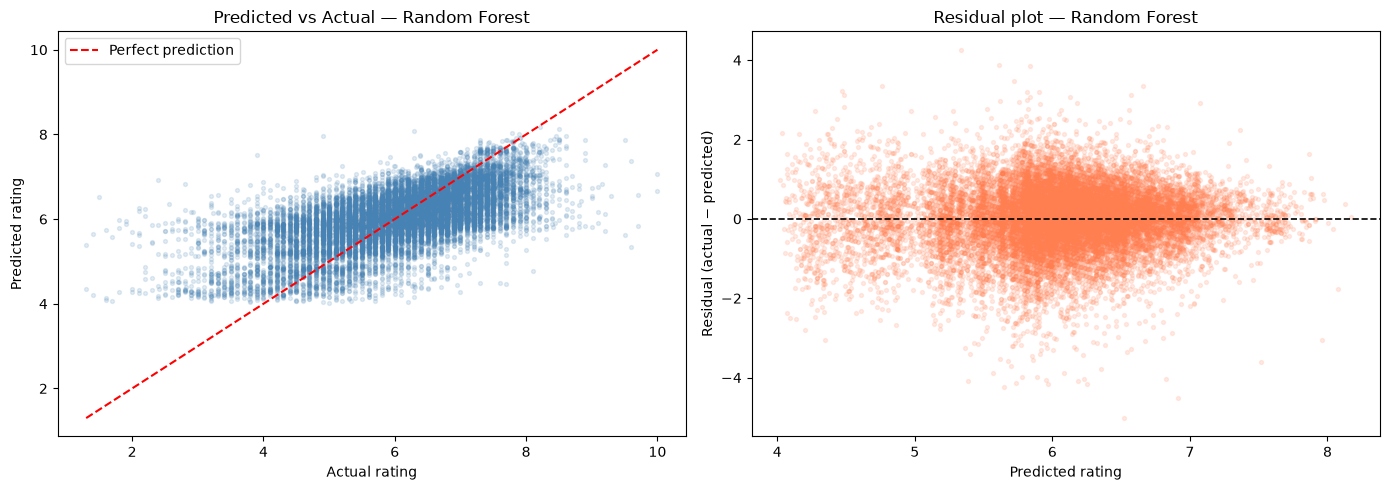

In [19]:
import matplotlib.gridspec as gridspec

# Use the best model — Random Forest
best_preds = results['Random Forest']['preds']
rf_model   = results['Random Forest']['model']

# ── Plot 1: Predicted vs Actual ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_preds, alpha=0.15, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual rating')
axes[0].set_ylabel('Predicted rating')
axes[0].set_title('Predicted vs Actual — Random Forest')
axes[0].legend()

# ── Plot 2: Residuals ─────────────────────────────────────────────────
residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.15, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted rating')
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].set_title('Residual plot — Random Forest')

plt.tight_layout()
plt.show()

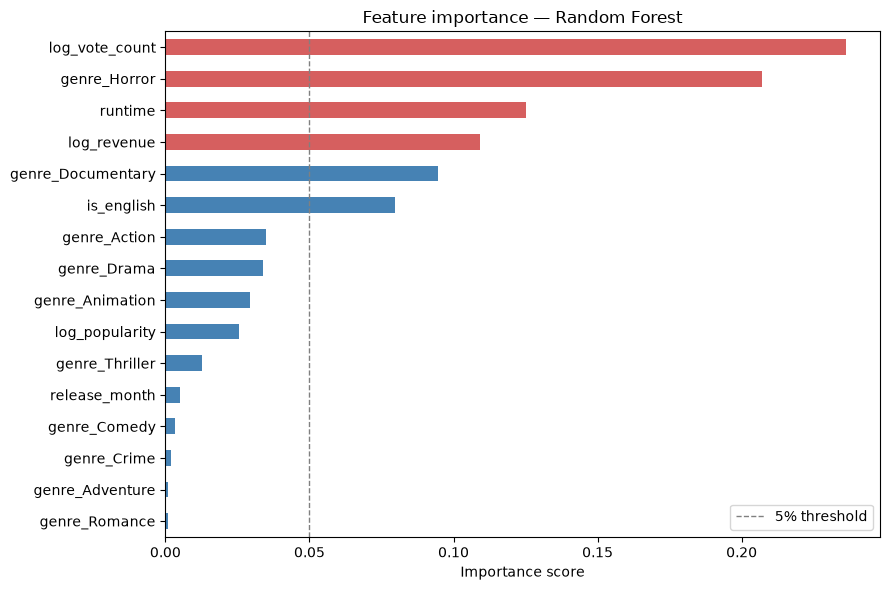

In [20]:
# ── Plot 3: Feature importance ────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#D65F5F' if v > 0.1 else 'steelblue' for v in importances]
importances.plot(kind='barh', color=colors)
plt.axvline(0.05, color='gray', linestyle='--',
            linewidth=1, label='5% threshold')
plt.title('Feature importance — Random Forest')
plt.xlabel('Importance score')
plt.legend()
plt.tight_layout()
plt.show()

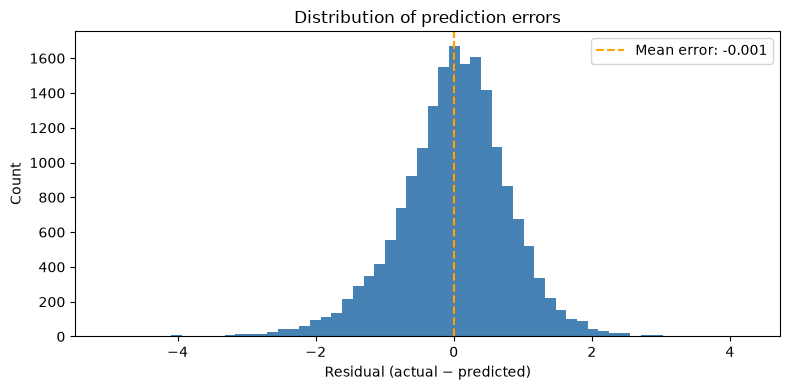

In [21]:
# ── Plot 4: Error distribution ────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='none')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.axvline(residuals.mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Mean error: {residuals.mean():.3f}')
plt.title('Distribution of prediction errors')
plt.xlabel('Residual (actual − predicted)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ── Summary table ─────────────────────────────────────────────────────
print("=" * 45)
print("  MODEL PERFORMANCE SUMMARY")
print("=" * 45)
for name, r in results.items():
    print(f"  {name:22s}  RMSE: {r['rmse']:.3f}  R²: {r['r2']:.3f}")
print("=" * 45)
print(f"\n  Best model : Random Forest")
print(f"  RMSE       : {results['Random Forest']['rmse']:.3f} rating points")
print(f"  R²         : {results['Random Forest']['r2']:.3f}")
print(f"\n  Interpretation:")
print(f"  On average, predictions are off by")
print(f"  {results['Random Forest']['rmse']:.2f} stars on a 10-point scale.")

  MODEL PERFORMANCE SUMMARY
  Linear Regression       RMSE: 0.871  R²: 0.308
  Ridge                   RMSE: 0.871  R²: 0.308
  Random Forest           RMSE: 0.809  R²: 0.403

  Best model : Random Forest
  RMSE       : 0.809 rating points
  R²         : 0.403

  Interpretation:
  On average, predictions are off by
  0.81 stars on a 10-point scale.


Not good enough - Encore!

In [23]:
# ── 1. Add era buckets — release_year had 0.00 correlation as a raw 
#       number, but grouped into eras it becomes meaningful ────────────
df['era'] = pd.cut(
    df['release_year'],
    bins=[1800, 1950, 1970, 1990, 2000, 2010, 2015, 2030],
    labels=['pre-1950', '1950s-70s', '1970s-90s',
            '2000s', '2010s', '2010-15', '2015+']
)

# ── 2. Vote credibility ratio — normalises popularity vs vote count ───
df['vote_pop_ratio'] = df['log_vote_count'] / (df['log_popularity'] + 1)

# ── 3. Revenue-to-budget ratio — proxy for commercial success ─────────
df['rev_budget_ratio'] = df['log_revenue'] / (df['log_budget'] + 1)

# ── 4. Is it a major-language film? ──────────────────────────────────
major_langs = {'en', 'fr', 'es', 'de', 'ja', 'zh', 'ko', 'it', 'pt'}
df['is_major_language'] = df['original_language'].isin(major_langs).astype(int)

# ── 5. One-hot encode era ─────────────────────────────────────────────
era_dummies = pd.get_dummies(df['era'], prefix='era').astype(int)
df = pd.concat([df, era_dummies], axis=1)

era_features = [c for c in df.columns if c.startswith('era_')]
print("Era features added:", era_features)

Era features added: ['era_pre-1950', 'era_1950s-70s', 'era_1970s-90s', 'era_2000s', 'era_2010s', 'era_2010-15', 'era_2015+']


In [24]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ── Updated feature list ──────────────────────────────────────────────
genre_features = [f'genre_{g}' for g in top_genres]

FEATURES_V2 = [
    'log_revenue',
    'log_budget',          # add back — useful in ratio context
    'runtime',
    'log_popularity',
    'log_vote_count',
    'is_english',
    'is_major_language',
    'release_month',
    'vote_pop_ratio',      # new
    'rev_budget_ratio',    # new
] + genre_features + era_features

model_df2 = df[FEATURES_V2 + [TARGET]].dropna()
print(f"V2 modeling dataset: {model_df2.shape}")

X2 = model_df2[FEATURES_V2]
y2 = model_df2[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# ── Train upgraded models ─────────────────────────────────────────────
models_v2 = {
    'Random Forest v2': RandomForestRegressor(
        n_estimators=200,       # more trees
        max_depth=15,           # deeper trees
        min_samples_leaf=5,     # tighter fit
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,          # prevents overfitting
        random_state=42
    ),
}

results_v2 = {}

for name, model in models_v2.items():
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)
    rmse  = np.sqrt(mean_squared_error(y2_test, preds))
    r2    = r2_score(y2_test, preds)
    results_v2[name] = {'model': model, 'preds': preds,
                        'rmse': rmse, 'r2': r2}
    print(f"{name:22s} → RMSE: {rmse:.3f}  R²: {r2:.3f}")

# Compare against original
print(f"\n{'Original RF':22s} → RMSE: {results['Random Forest']['rmse']:.3f}"
      f"  R²: {results['Random Forest']['r2']:.3f}")

V2 modeling dataset: (92464, 28)
Random Forest v2       → RMSE: 0.737  R²: 0.504
Gradient Boosting      → RMSE: 0.737  R²: 0.505

Original RF            → RMSE: 0.809  R²: 0.403


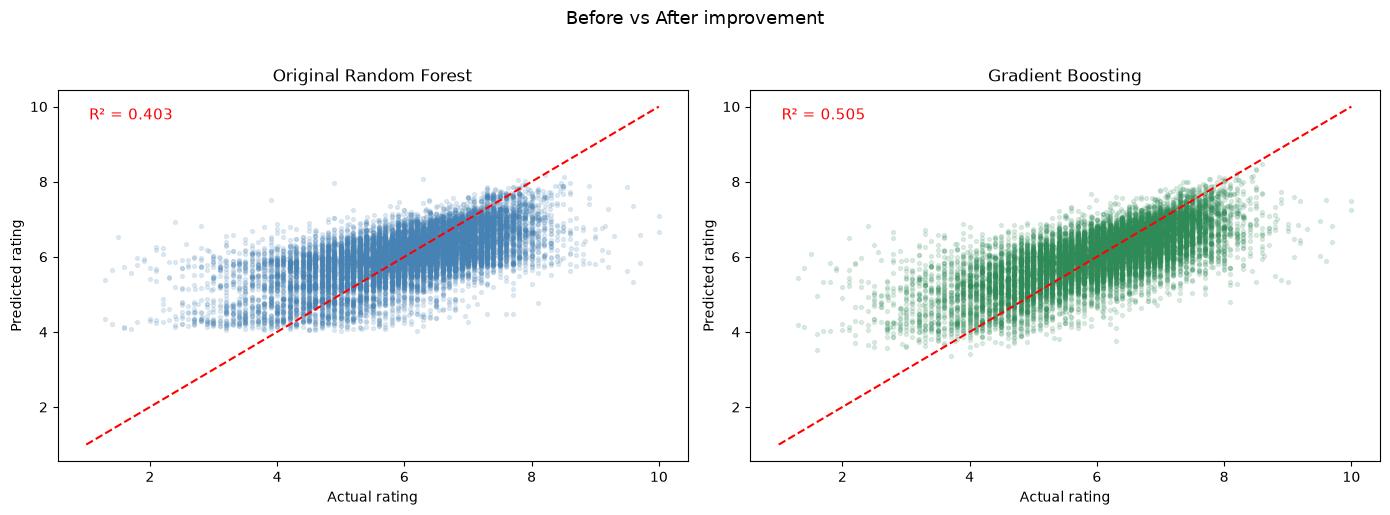

In [27]:
# Pick the best v2 model to plot
best_name = min(results_v2, key=lambda n: results_v2[n]['rmse'])
best_v2   = results_v2[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original RF
axes[0].scatter(y_test, results['Random Forest']['preds'],
                alpha=0.15, s=8, color='steelblue')
axes[0].plot([1, 10], [1, 10], 'r--', linewidth=1.5)
axes[0].set_title('Original Random Forest')
axes[0].set_xlabel('Actual rating')
axes[0].set_ylabel('Predicted rating')
axes[0].text(0.05, 0.92, f"R² = {results['Random Forest']['r2']:.3f}",
             transform=axes[0].transAxes, fontsize=11, color='red')

# Best v2 model
axes[1].scatter(y2_test, best_v2['preds'],
                alpha=0.15, s=8, color='seagreen')
axes[1].plot([1, 10], [1, 10], 'r--', linewidth=1.5)
axes[1].set_title(f'{best_name}')
axes[1].set_xlabel('Actual rating')
axes[1].set_ylabel('Predicted rating')
axes[1].text(0.05, 0.92, f"R² = {best_v2['r2']:.3f}",
             transform=axes[1].transAxes, fontsize=11, color='red')

plt.suptitle('Before vs After improvement', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Try XGBoost

In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(X2_train, y2_train)
xgb_preds = xgb.predict(X2_test)

rmse = np.sqrt(mean_squared_error(y2_test, xgb_preds))
r2   = r2_score(y2_test, xgb_preds)
print(f"XGBoost → RMSE: {rmse:.3f}  R²: {r2:.3f}")

XGBoost → RMSE: 0.708  R²: 0.542


Final Visualizations

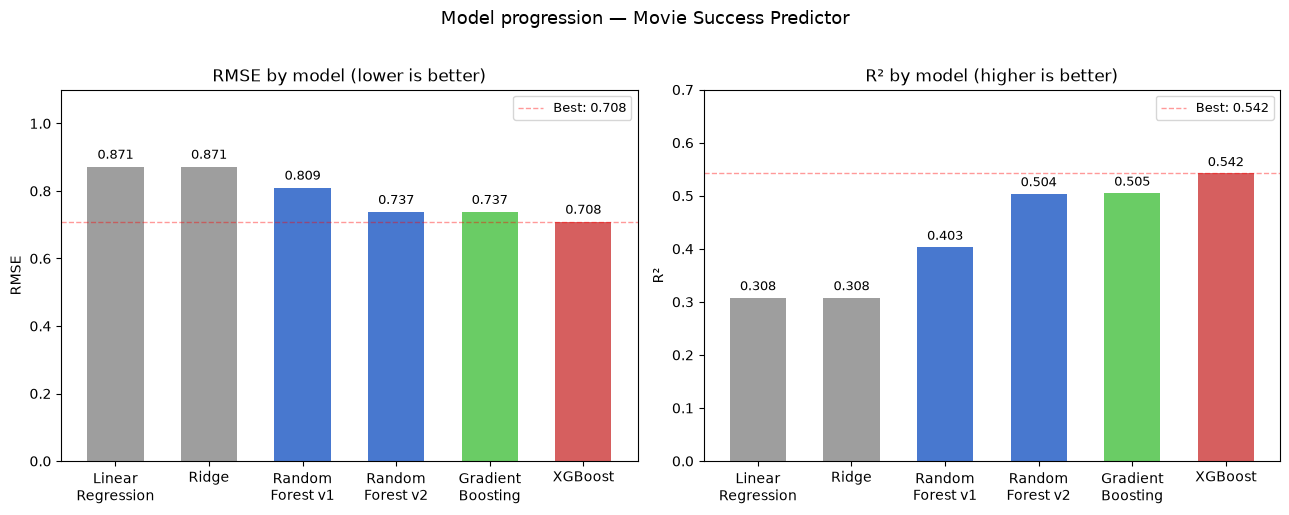

In [28]:
# ── All results in one place ──────────────────────────────────────────
all_results = {
    'Linear\nRegression': {'rmse': 0.871, 'r2': 0.308},
    'Ridge':              {'rmse': 0.871, 'r2': 0.308},
    'Random\nForest v1':  {'rmse': 0.809, 'r2': 0.403},
    'Random\nForest v2':  {'rmse': 0.737, 'r2': 0.504},
    'Gradient\nBoosting': {'rmse': 0.737, 'r2': 0.505},
    'XGBoost':            {'rmse': 0.708, 'r2': 0.542},
}

names = list(all_results.keys())
rmses = [all_results[n]['rmse'] for n in names]
r2s   = [all_results[n]['r2']   for n in names]

# Color: gray for baselines, blue for RF, green for boosting winner
colors = ['#9E9E9E', '#9E9E9E', '#4878CF', '#4878CF', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── RMSE bar chart ────────────────────────────────────────────────────
bars = axes[0].bar(names, rmses, color=colors, edgecolor='none', width=0.6)
axes[0].set_title('RMSE by model (lower is better)', fontsize=12)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(rmses[-1], color='red', linestyle='--',
                linewidth=1, alpha=0.4, label=f'Best: {rmses[-1]}')
for bar, v in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 v + 0.015, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9.5)
axes[0].legend(fontsize=9)

# ── R² bar chart ──────────────────────────────────────────────────────
bars2 = axes[1].bar(names, r2s, color=colors, edgecolor='none', width=0.6)
axes[1].set_title('R² by model (higher is better)', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 0.7)
axes[1].axhline(r2s[-1], color='red', linestyle='--',
                linewidth=1, alpha=0.4, label=f'Best: {r2s[-1]}')
for bar, v in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 v + 0.008, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9.5)
axes[1].legend(fontsize=9)

plt.suptitle('Model progression — Movie Success Predictor', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

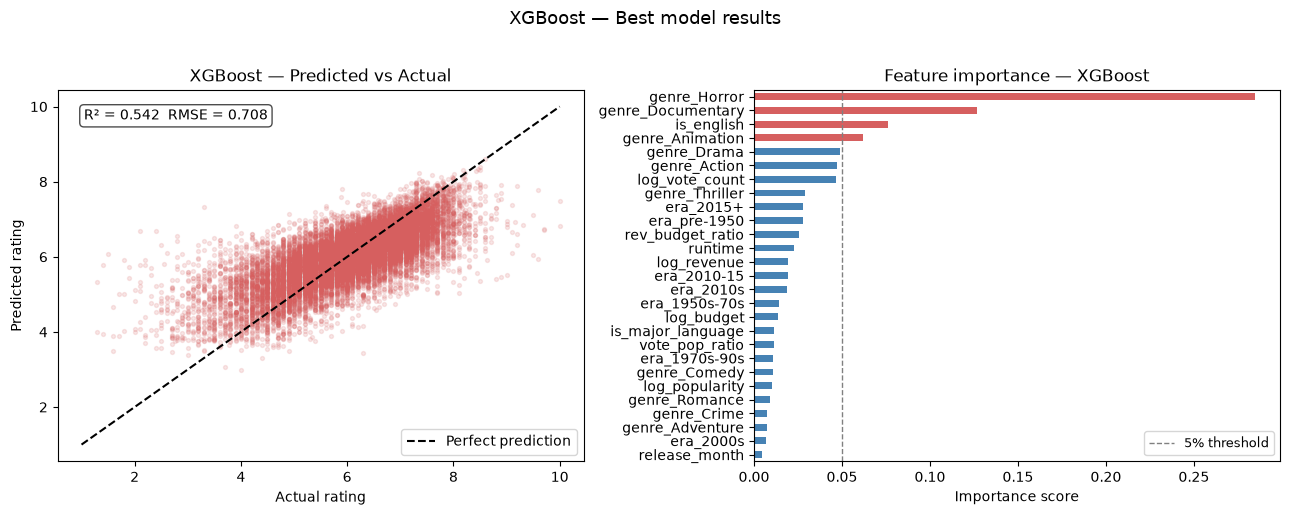

In [29]:
# ── Predicted vs Actual — XGBoost (best model) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y2_test, xgb_preds, alpha=0.15, s=8, color='#D65F5F')
axes[0].plot([1, 10], [1, 10], 'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual rating')
axes[0].set_ylabel('Predicted rating')
axes[0].set_title('XGBoost — Predicted vs Actual')
axes[0].text(0.05, 0.92, f'R² = 0.542  RMSE = 0.708',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].legend()

# ── XGBoost feature importance ────────────────────────────────────────
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES_V2)
xgb_imp = xgb_imp.sort_values(ascending=True)

colors_imp = ['#D65F5F' if v > 0.05 else 'steelblue' for v in xgb_imp]
xgb_imp.plot(kind='barh', color=colors_imp, ax=axes[1])
axes[1].axvline(0.05, color='gray', linestyle='--',
                linewidth=1, label='5% threshold')
axes[1].set_title('Feature importance — XGBoost')
axes[1].set_xlabel('Importance score')
axes[1].legend(fontsize=9)

plt.suptitle('XGBoost — Best model results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()